# AdaBoost: Weak Learners, Strong Decisions

Many classification problems are easy to state but hard to separate with a single simple rule. AdaBoost turns this limitation into an advantage: it repeatedly fits a weak rule, then changes the sampling distribution so that the next rule concentrates on examples the current ensemble still finds difficult. The resulting classifier can be strongly nonlinear even when every individual learner is only a threshold across a line.

This notebook follows the entire mechanism geometrically. We will see how weighted classification error selects a weak learner, how the exponential loss decays, how probability mass migrates towards hard observations, and how the ensemble boundary is assembled round by round.

For labels $y_i\in\{-1,+1\}$, AdaBoost constructs the score
$$
F_T(x)=\sum_{t=1}^T \alpha_t h_{j_t}(x),\qquad \widehat y(x)=\operatorname{sign}(F_T(x)).
$$
At round $t$, the selected learner minimizes its weighted error $\varepsilon_t=\sum_i D_t(i)\,\mathbf{1}_{h_{j_t}(x_i)\ne y_i}$, then
$$
\alpha_t=\frac12\log\frac{1-\varepsilon_t}{\varepsilon_t},\qquad\nD_{t+1}(i)=\frac{D_t(i)\exp\!\big(-\alpha_t y_i h_{j_t}(x_i)\big)}{Z_t}.
$$
Thus correct, high-margin observations lose relative weight, while mistakes become influential in the next round.

## Environment and notation

This cell sets plotting style and imports. We will represent the sample as a matrix $X\in\mathbb{R}^{n\times 2}$ and labels as $y\in\{-1,+1\}^n$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

plt.rcParams['figure.dpi'] = 120
rng = np.random.default_rng(2)

## Synthetic dataset

We build a two-class planar distribution with partial overlap. This provides a clear setting where single linear separators are weak, but a boosted ensemble can succeed.

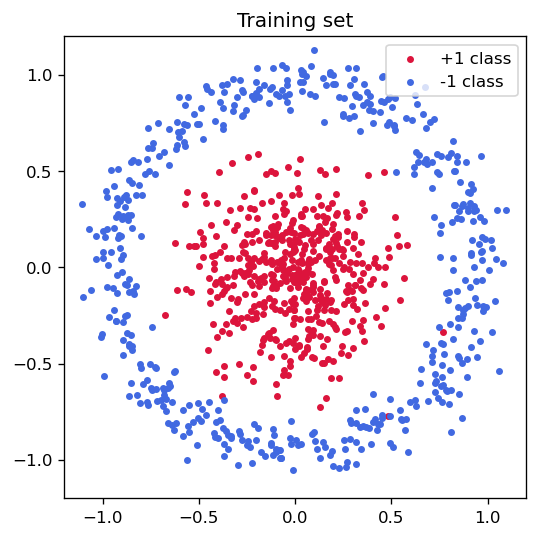

In [2]:
n = 1000
n_half = n // 2

theta = 2 * np.pi * rng.random(n_half)
R = 0.95
r = R * (1 + 0.08 * rng.standard_normal(n_half))
x_ring = np.c_[np.cos(theta) * r, np.sin(theta) * r]
x_blob = 0.25 * rng.standard_normal((n_half, 2))

X = np.vstack([x_blob, x_ring])
y = np.r_[np.ones(n_half), -np.ones(n_half)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(X[y > 0, 0], X[y > 0, 1], s=10, c='crimson', label='+1 class')
ax.scatter(X[y < 0, 0], X[y < 0, 1], s=10, c='royalblue', label='-1 class')
ax.set_title('Training set')
ax.set_aspect('equal')
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.legend(loc='upper right')
plt.show()

## Weak learner family

We sample many oriented threshold classifiers
$$
h_j(x)=\operatorname{sign}(\langle u_j,x\rangle-t_j),
$$
then flip their orientation when needed so each has correlation with labels.

In [3]:
r = 120
angles = 2 * np.pi * rng.random(r)
u = np.vstack([np.cos(angles), np.sin(angles)])
t = 1.2 * (2 * rng.random(r) - 1)

raw = X @ u - t
acc = (np.sign(raw) == y[:, None]).mean(axis=0)
sigma = np.sign(acc - 0.5 + 1e-10)
H = np.sign(raw * sigma[None, :])
H[H == 0] = 1
E = (H != y[:, None]).astype(float)

print('Weak learner error range:', E.mean(axis=0).min(), E.mean(axis=0).max())

Weak learner error range: 0.33 0.5


## Local decision geometries

Before boosting, it is helpful to inspect individual weak learners and their induced partition of the plane.

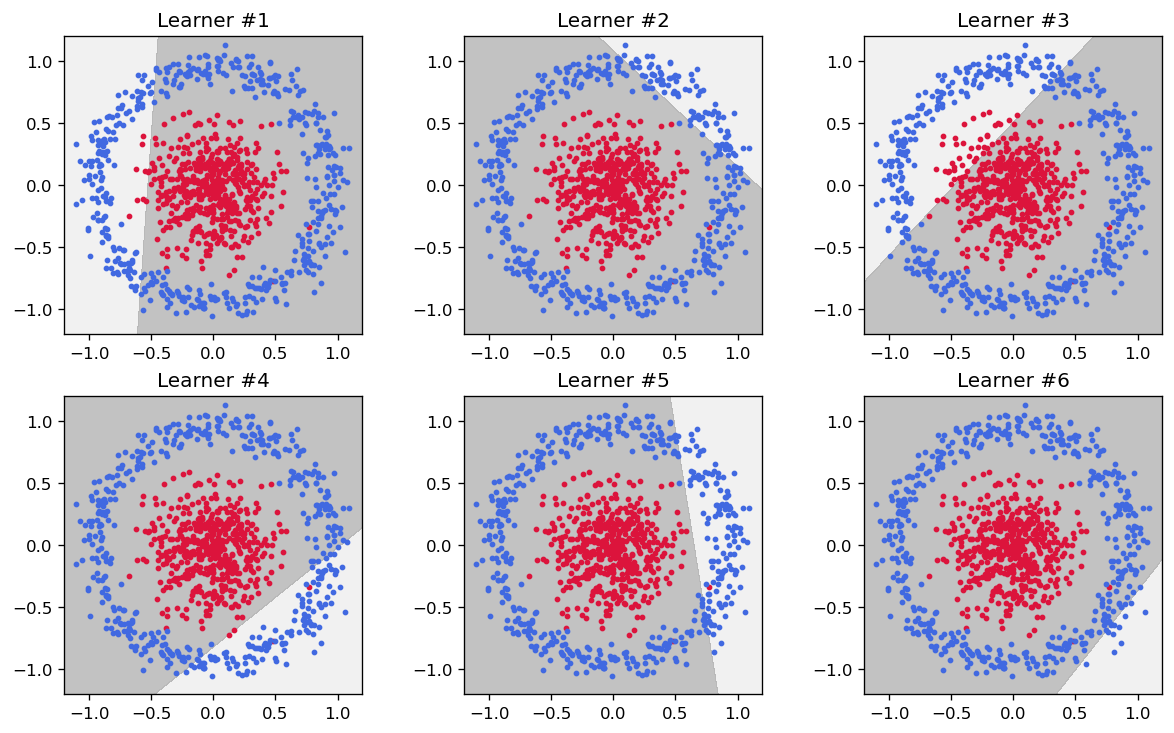

In [4]:
s = np.linspace(-1.2, 1.2, 300)
U, V = np.meshgrid(s, s)
Z = np.c_[U.ravel(), V.ravel()]

fig, axes = plt.subplots(2, 3, figsize=(10, 6), constrained_layout=True)
for k, ax in enumerate(axes.flat):
    pred = np.sign((Z @ u[:, k] - t[k]) * sigma[k]).reshape(U.shape)
    pred[pred == 0] = 1
    ax.contourf(U, V, pred, levels=[-1, 0, 1], cmap='Greys', alpha=0.35)
    ax.scatter(X[y > 0, 0], X[y > 0, 1], s=6, c='crimson')
    ax.scatter(X[y < 0, 0], X[y < 0, 1], s=6, c='royalblue')
    ax.set_aspect('equal')
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_title(f'Learner #{k+1}')
plt.show()

## Boosting dynamics

This implementation follows the exact AdaBoost update with the exponential surrogate
$$
\mathcal L_{\exp}(w)=\frac1n\sum_{i=1}^n e^{-y_i(Hw)_i}.
$$
At each round we pick the best coordinate (weak learner) under the current distribution $D_t$.

In [5]:
def run_adaboost(H, E, y, n_iter=500):
    n, r = H.shape
    w = np.zeros(r)
    D = np.ones(n) / n
    exp_losses = []
    learner_ids = []
    alphas = []
    D_hist = [D.copy()]

    for _ in range(n_iter):
        F = H @ w
        exp_losses.append(np.mean(np.exp(-y * F)))
        weighted_errors = (D[:, None] * E).sum(axis=0)
        j = np.argmin(weighted_errors)
        eps = np.clip(weighted_errors[j], 1e-8, 1 - 1e-8)
        a = 0.5 * np.log((1 - eps) / eps)
        w[j] += a
        D *= np.exp(-a * y * H[:, j])
        D /= D.sum()
        learner_ids.append(int(j))
        alphas.append(float(a))
        D_hist.append(D.copy())

    return {
        'w': w,
        'exp_losses': np.array(exp_losses),
        'learner_ids': np.array(learner_ids),
        'alphas': np.array(alphas),
        'D_hist': D_hist,
    }

boost = run_adaboost(H, E, y, n_iter=500)

## Optimization, weights, and ensemble geometry

The exponential loss is a global measure of fit, whereas $D_t$ reveals *where* the algorithm is paying attention. The cumulative coefficient vector after $t$ rounds is
$$
w^{(t)}_j=\sum_{s\leq t:\,j_s=j}\alpha_s,
$$
so the partial score is $F_t(x)=\sum_j w^{(t)}_j h_j(x)$. We first reconstruct these partial ensembles; they will support both the static snapshots and the interactive view below.


In [6]:
W_hist = np.zeros((len(boost['alphas']) + 1, r))
for step, (learner, alpha) in enumerate(zip(boost['learner_ids'], boost['alphas']), start=1):
    W_hist[step] = W_hist[step - 1]
    W_hist[step, learner] += alpha

def score_field(round_idx):
    raw_grid = Z @ u - t
    H_grid = np.where(raw_grid >= 0, 1.0, -1.0) * sigma
    return (H_grid @ W_hist[round_idx]).reshape(U.shape)

def draw_ensemble(ax, round_idx, *, weighted=False):
    score = score_field(round_idx)
    scale = max(0.5, np.quantile(np.abs(score), 0.98))
    levels = np.linspace(-scale, scale, 17)
    ax.contourf(U, V, np.clip(score, -scale, scale), levels=levels,
                cmap='coolwarm', alpha=0.48, extend='both')
    if np.ptp(score) > 1e-12:
        ax.contour(U, V, score, levels=[0], colors='black', linewidths=1.8)

    sizes = np.full(len(X), 16.0)
    if weighted:
        D = boost['D_hist'][round_idx]
        sizes = 14 + 320 * D / D.max()
    ax.scatter(X[y > 0, 0], X[y > 0, 1], s=sizes[y > 0], c='crimson',
               edgecolors='white', linewidths=0.25, label='+1')
    ax.scatter(X[y < 0, 0], X[y < 0, 1], s=sizes[y < 0], c='royalblue',
               edgecolors='white', linewidths=0.25, label='-1')
    ax.set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), aspect='equal')


### Loss decay and concentration of attention

The point area below is proportional to $D_t(i)$. Since the update contains $\exp(-\alpha_t y_i h_{j_t}(x_i))$, an incorrectly classified point is multiplied by $e^{+\alpha_t}$ before normalization. The panels therefore make the adaptive focus of boosting visible rather than merely reporting a scalar loss.


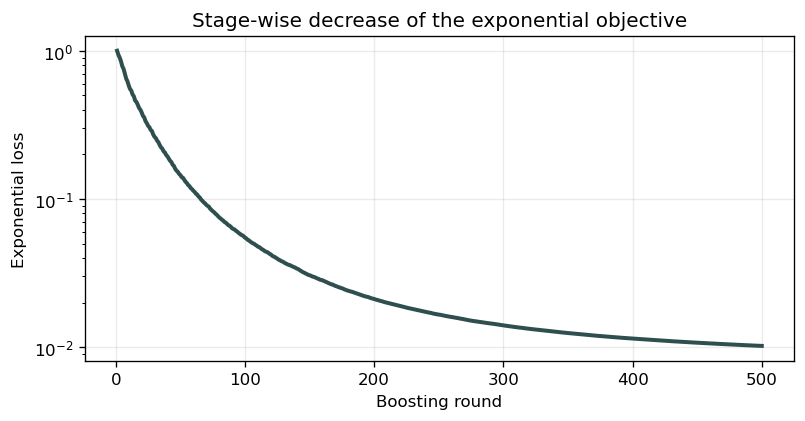

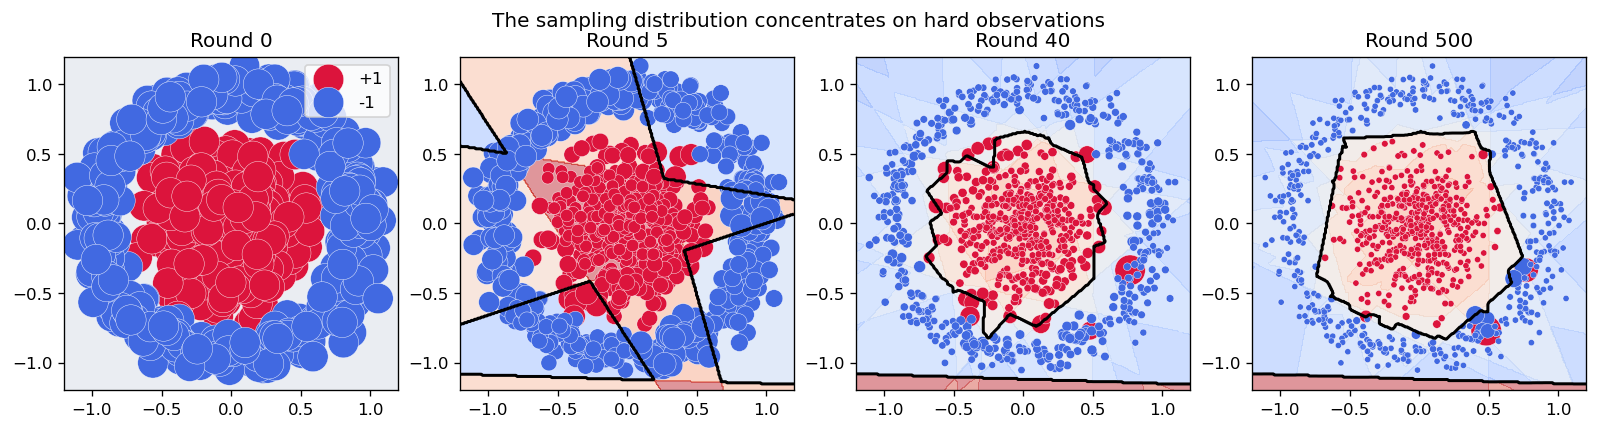

In [7]:
fig, ax = plt.subplots(figsize=(6.6, 3.4), constrained_layout=True)
ax.semilogy(np.arange(1, len(boost['exp_losses']) + 1), boost['exp_losses'], lw=2.4, color='darkslategray')
ax.set(xlabel='Boosting round', ylabel='Exponential loss', title='Stage-wise decrease of the exponential objective')
ax.grid(alpha=0.25)
plt.show()

check_idx = [0, 5, 40, len(boost['D_hist']) - 1]
fig, axes = plt.subplots(1, len(check_idx), figsize=(13.2, 3.35), constrained_layout=True)
for ax, round_idx in zip(axes, check_idx):
    draw_ensemble(ax, round_idx, weighted=True)
    ax.set_title(f'Round {round_idx}')
axes[0].legend(loc='upper right', frameon=True)
fig.suptitle('The sampling distribution concentrates on hard observations', y=1.03)
plt.show()


### A boundary assembled over rounds

The level set $F_t(x)=0$ is the current decision boundary. Early ensembles are dominated by a few half-planes; after repeated corrections, their weighted sum bends around the inner cluster. The score color indicates confidence: its sign determines the prediction and its magnitude is a margin-like measure.


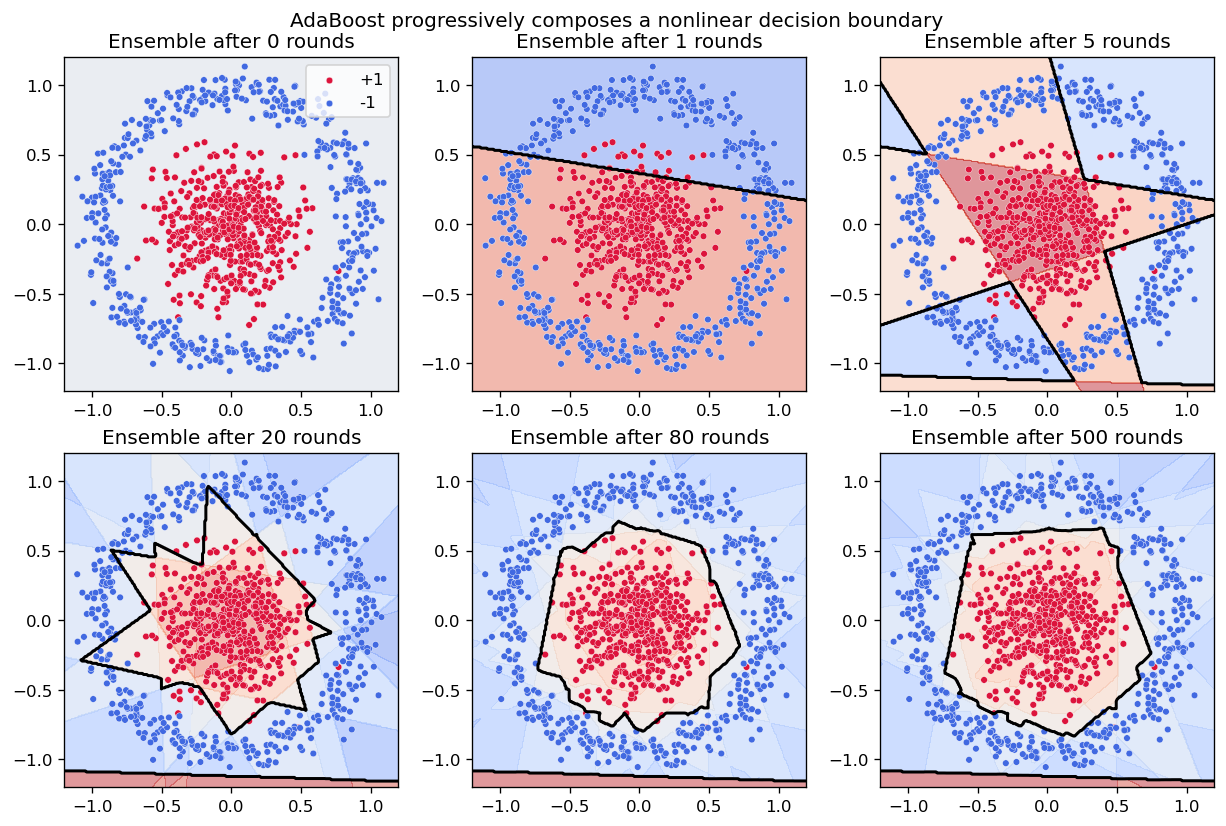

In [8]:
boundary_rounds = [0, 1, 5, 20, 80, len(boost['alphas'])]
fig, axes = plt.subplots(2, 3, figsize=(10.2, 6.6), constrained_layout=True)
for ax, round_idx in zip(axes.flat, boundary_rounds):
    draw_ensemble(ax, round_idx)
    ax.set_title(f'Ensemble after {round_idx} rounds')
axes[0, 0].legend(loc='upper right', frameon=True)
fig.suptitle('AdaBoost progressively composes a nonlinear decision boundary', y=1.02)
plt.show()


### Final classifier and training margins

For the fitted ensemble, the signed training margin is $m_i=y_iF_T(x_i)$. A positive margin means correct classification; larger positive values indicate a more confident decision. The final boundary is shown alongside the empirical margin distribution, which distinguishes residual errors from well-classified observations.


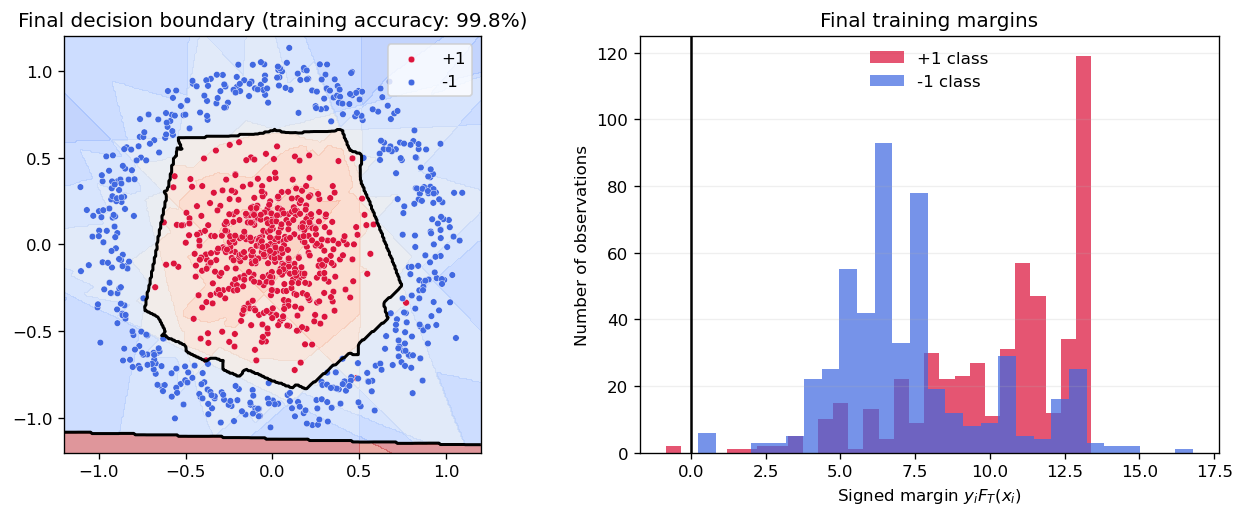

In [9]:
final_round = len(boost['alphas'])
final_scores = H @ W_hist[final_round]
margins = y * final_scores
train_accuracy = np.mean(margins > 0)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), constrained_layout=True)
draw_ensemble(axes[0], final_round)
axes[0].set_title(f'Final decision boundary (training accuracy: {train_accuracy:.1%})')
axes[0].legend(loc='upper right', frameon=True)

axes[1].hist(margins[y > 0], bins=28, alpha=0.72, color='crimson', label='+1 class')
axes[1].hist(margins[y < 0], bins=28, alpha=0.72, color='royalblue', label='-1 class')
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set(xlabel=r'Signed margin $y_iF_T(x_i)$', ylabel='Number of observations', title='Final training margins')
axes[1].legend(frameon=False)
axes[1].grid(axis='y', alpha=0.2)
plt.show()


## Interactive ensemble boundary

Move the slider through the boosting rounds to inspect how the score field and the reweighted sample co-evolve. This optional exploration cell is deliberately isolated from the numerical computation, so the static figures above remain available in automated notebook exports.


In [ ]:
@interact(round_idx=IntSlider(value=40, min=0, max=len(boost['alphas']), step=1,
                                description='Round', continuous_update=False))
def explore_ensemble(round_idx):
    fig, ax = plt.subplots(figsize=(5.2, 5.0), constrained_layout=True)
    draw_ensemble(ax, round_idx, weighted=True)
    current_margin = y * (H @ W_hist[round_idx])
    ax.set_title(f'Round {round_idx}: accuracy {(current_margin > 0).mean():.1%}')
    ax.legend(loc='upper right', frameon=True)
    plt.show()


## Bibliographical resources

- Yoav Freund and Robert E. Schapire, *A Decision-Theoretic Generalization of On-Line Learning and an Application to Boosting*, 1997.
- Robert E. Schapire and Yoram Singer, *Improved Boosting Algorithms Using Confidence-rated Predictions*, 1999.
- Trevor Hastie, Robert Tibshirani, and Jerome Friedman, *The Elements of Statistical Learning*, Chapter 10.
- Peter Buhlmann and Torsten Hothorn, *Boosting Algorithms: Regularization, Prediction and Model Fitting*, 2007.
